In [1]:
## Load StyleGAN2-ADA network

import sys
import os

# Clone the repo
if not os.path.exists('stylegan2-ada-pytorch'):
    print("Cloning StyleGAN2 repo...")
    !git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git

# Add the repo to Python's search path
repo_path = os.path.abspath('stylegan2-ada-pytorch')
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)
    print(f"Added {repo_path} to system path.")

# Install Ninja (required for StyleGAN)
!pip install ninja

print("Setup complete! Now try running your imports again.")

Cloning StyleGAN2 repo...
Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 23.15 MiB/s, done.
Resolving deltas: 100% (57/57), done.
Added /kaggle/working/stylegan2-ada-pytorch to system path.
Setup complete! Now try running your imports again.


In [2]:
# Getting the generator of the FFHQ network which we will call G:

import torch
import pickle
import dnnlib
import legacy

# Load the FFHQ network
network_pkl = 'https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl'

print(f'Loading network from {network_pkl}...')
device = torch.device('cuda')
with dnnlib.util.open_url(network_pkl) as f:
  # G is the generator of the network
  G = legacy.load_network_pkl(f)['G_ema'].to(device) # G_ema = Exponential Moving Average (smoother weights)
  print('Model loaded!')

Loading network from https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl...
Model loaded!


In [3]:
# Load the classifier pre-trained gender classifier
import torch
import torch.nn as nn
from torchvision import models, transforms
import torch.nn.functional as F

# Define the Model Architecture
# We need to tell this notebook what a "ResNet" looks like before we can load weights.
classifier = models.resnet18(weights=None) # We don't need ImageNet weights, we have our own!
classifier.fc = nn.Linear(classifier.fc.in_features, 1)

# Load the trained weights
device = torch.device('cuda')

# The full path to the Input folder
model_path = '/kaggle/input/gender-classifier/pytorch/default/1/classifier_gender.pth'

print(f"Loading model from: {model_path}")
state_dict = torch.load(model_path, map_location=device)
classifier.load_state_dict(state_dict)

classifier = classifier.to(device)
classifier.eval()

print("Classifier loaded successfully!")

Loading model from: /kaggle/input/gender-classifier/pytorch/default/1/classifier_gender.pth
Classifier loaded successfully!


In [4]:
# Bridgin the StyleGAN (-1 to 1) range to the Classifier (Normalized) range
def get_classifier_predictions(w_vectors, generator, classifier):
    """
    Takes W-vectors, generates images, and returns gender scores. 1 is male 0 is female.
    """
    # Generate Images from W
    # noise_mode='const' ensures deterministic results
    generated_imgs = generator.synthesis(w_vectors, noise_mode='const')
    
    # Preprocess for classifier
    # Convert [-1, 1] range to [0, 1]
    imgs_01 = (generated_imgs + 1) * 0.5
    imgs_01 = torch.clamp(imgs_01, 0, 1)
    
    # Resize to 224x224 with bilinear interpolation
    imgs_resized = F.interpolate(imgs_01, size=(224, 224), mode='bilinear', align_corners=False)
    
    # Normalize with Standard ImageNet stats
    # Manual normalization for a batch of tensors
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
    imgs_norm = (imgs_resized - mean) / std
    
    # Predict
    with torch.no_grad():
        logits = classifier(imgs_norm)
        probs = torch.sigmoid(logits) # Convert to probability 0.0 - 1.0
        
    return probs, generated_imgs

Setting up PyTorch plugin "bias_act_plugin"... 

W0105 21:13:10.534000 24 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0105 21:13:10.534000 24 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.


Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... 

W0105 21:13:33.113000 24 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0105 21:13:33.113000 24 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.


Done.


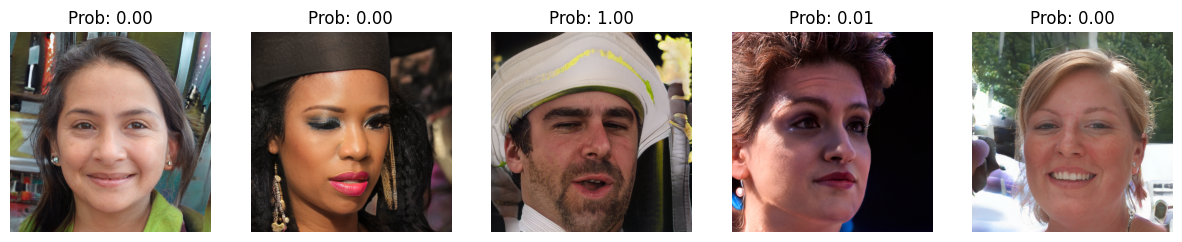

In [5]:
import matplotlib.pyplot as plt

# Run a test on the classifier

z_test = torch.randn(5,512, device=device)
w_test = G.mapping(z_test, c=None)

probs, generated_imgs = get_classifier_predictions(w_test, G, classifier)

fig, axes = plt.subplots(1, 5, figsize=(15, 5)) # Adjusted figsize for better visibility
for i in range(len(axes)):
    axes[i].axis('off')
    # 1. Move to CPU
    # 2. Permute dimensions from (C, H, W) -> (H, W, C)
    # 3. Scale from [-1, 1] -> [0, 1]
    img = generated_imgs[i].cpu().permute(1, 2, 0).clamp(-1, 1)
    img = (img + 1) / 2.0 
    
    axes[i].imshow(img)
    axes[i].set_title(f"Prob: {probs[i].item():.2f}")

plt.show()

In [6]:
# Generate the dataset
# this part takes the most time to run at around 12 mins

import numpy as np
from tqdm import tqdm # Progress bar

# Settings
num_samples = 20000
batch_size = 16 
w_vectors = []
labels = []

print(f"Generating {num_samples} samples...")

with torch.no_grad(): # Disable gradients for faster generation
    for i in tqdm(range(0, num_samples, batch_size)):
        # Sample Z
        current_batch_size = min(batch_size, num_samples - i)
        z = torch.randn(current_batch_size, 512, device=device)
        
        # Map to W
        w = G.mapping(z, c=None)
        
        # Get Labels
        # We only need the probabilities so we discard the image returned with _
        probs, _ = get_classifier_predictions(w, G, classifier)
        
        # Store Data (Move to CPU to save RAM)
        w_vectors.append(w.cpu())
        labels.append(probs.cpu())

# Concatenate all batches into single huge tensors
w_dataset = torch.cat(w_vectors, dim=0)       # Shape: [20000, 18, 512] or [20000, 512] depending on G
labels_dataset = torch.cat(labels, dim=0)     # Shape: [20000, 1]

print(f"Dataset Generated!")
print(f"W shape: {w_dataset.shape}")
print(f"Labels shape: {labels_dataset.shape}")

# Save to disk 
torch.save(w_dataset, 'w_dataset_20k.pt')
torch.save(labels_dataset, 'labels_dataset_20k.pt')
print("Saved to w_dataset_20k.pt and labels_dataset_20k.pt")

Generating 20000 samples...


100%|██████████| 1250/1250 [11:49<00:00,  1.76it/s]


Dataset Generated!
W shape: torch.Size([20000, 18, 512])
Labels shape: torch.Size([20000, 1])
Saved to w_dataset_20k.pt and labels_dataset_20k.pt


In [7]:
import torch.nn as nn
import math

class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.fc = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return x + self.fc(self.act(x))

class LatentDiffusionMLP(nn.Module):
    def __init__(self, input_dim=512, time_dim=64, hidden_dim=1024):
        super().__init__()
        
        # Time Embedding (Sinusoidal is standard for diffusion)
        self.time_dim = time_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )
        
        # Condition Embedding (for the label)
        # We map the single float label (0.0 to 1.0) to a vector
        self.cond_mlp = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        # Main Network (The "U-Net" equivalent for 1D)
        self.input_proj = nn.Linear(input_dim + time_dim + time_dim, hidden_dim)
        
        self.blocks = nn.Sequential(
            ResidualBlock(hidden_dim),
            ResidualBlock(hidden_dim),
            ResidualBlock(hidden_dim),
            ResidualBlock(hidden_dim),
        )
        
        self.output_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, t, c):
        # x: [batch, 512] (Noisy Latent)
        # t: [batch, 1]   (Timestep)
        # c: [batch, 1]   (Condition/Label)

        # Embed Time and Condition
        t_emb = self.time_mlp(t)
        c_emb = self.cond_mlp(c)
        
        # Concatenate Input + Time + Condition
        # We concatenate them along the feature dimension
        x_input = torch.cat([x, t_emb, c_emb], dim=1)
        
        # Pass through MLP
        h = self.input_proj(x_input)
        h = self.blocks(h)
        noise_pred = self.output_proj(h)
        
        return noise_pred

In [8]:
from torch.utils.data import TensorDataset, DataLoader

# Prepare the data and load the saved tensors
w_data = torch.load('w_dataset_20k.pt').to(device) # [20000, 18, 512]
labels_data = torch.load('labels_dataset_20k.pt').to(device)

# Slice W to be 1D suggested by hint 1
if len(w_data.shape) == 3:
    w_data = w_data[:, 0, :] # Shape becomes [20000, 512]

# Create DataLoader
dataset = TensorDataset(w_data, labels_data)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Setup Model & Optimizer
model = LatentDiffusionMLP().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

# Diffusion Schedules (Simple Linear Schedule)
num_timesteps = 1000
betas = torch.linspace(1e-4, 0.02, num_timesteps).to(device)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

def get_noisy_image(x_start, t):
    """Adds noise to the latent vector x_start at timestep t"""
    # x_start: [batch, 512]
    # t: [batch] (indices)
    
    sqrt_alpha_cumprod = torch.sqrt(alphas_cumprod[t])[:, None]
    sqrt_one_minus_alpha_cumprod = torch.sqrt(1 - alphas_cumprod[t])[:, None]
    
    epsilon = torch.randn_like(x_start)
    return sqrt_alpha_cumprod * x_start + sqrt_one_minus_alpha_cumprod * epsilon, epsilon

# Training Loop
epochs = 50 
print("Starting Training...")

for epoch in range(epochs):
    epoch_loss = 0
    for w_batch, c_batch in dataloader:
        optimizer.zero_grad()
        
        batch_size = w_batch.shape[0]
        
        # Sample random timesteps
        t = torch.randint(0, num_timesteps, (batch_size,), device=device)
        
        # Add Noise (Forward Process)
        noisy_w, noise_real = get_noisy_image(w_batch, t)
        
        # Classifier-Free Guidance (CFG) Setup
        if torch.rand(1).item() < 0.1:
            c_batch = torch.zeros_like(c_batch)
            
        # Predict Noise
        t_input = (t.float() / num_timesteps).unsqueeze(1)
        
        noise_pred = model(noisy_w, t_input, c_batch)
        
        # Loss
        loss = loss_fn(noise_pred, noise_real)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss / len(dataloader):.5f}")

print("Training Complete!")
torch.save(model.state_dict(), 'diffusion_model.pth')

Starting Training...
Epoch 5/50 | Loss: 0.15955
Epoch 10/50 | Loss: 0.16211
Epoch 15/50 | Loss: 0.15708
Epoch 20/50 | Loss: 0.15665
Epoch 25/50 | Loss: 0.15959
Epoch 30/50 | Loss: 0.15771
Epoch 35/50 | Loss: 0.15721
Epoch 40/50 | Loss: 0.15540
Epoch 45/50 | Loss: 0.15897
Epoch 50/50 | Loss: 0.15586
Training Complete!


Sampling: 100%|██████████| 200/200 [00:00<00:00, 1140.16it/s]


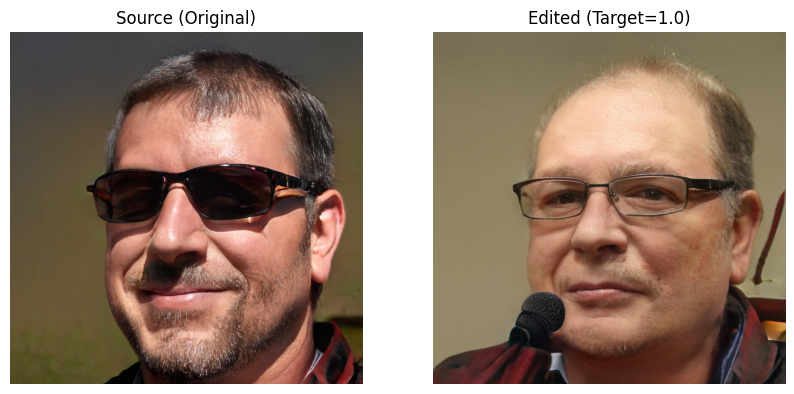

In [9]:
@torch.no_grad()
def sde_edit(w_source, target_label, start_t, guidance_scale=2.0):
    """
    Modifies w_source to match target_label using the diffusion model.
    """
    # Forward Process (Destruction)
    # Add noise to the source vector up to 'start_t'
    # We create a batch of 1 for the start_t
    t_tensor = torch.full((1,), start_t, device=device, dtype=torch.long)
    
    noisy_w, _ = get_noisy_image(w_source, t_tensor)
    
    # Reverse Process (Reconstruction)
    current_w = noisy_w
    
    # We loop backwards from start_t to 0
    for t in tqdm(reversed(range(0, start_t)), desc="Sampling", total=start_t):
        t_tensor = torch.full((1,), t, device=device, dtype=torch.long)
        t_input = (t_tensor.float() / num_timesteps).unsqueeze(1)
        
        # Classifier-Free Guidance
        # We run the model twice: once with the label, once without
        c_target = torch.full((1, 1), target_label, device=device).float()
        c_null = torch.zeros((1, 1), device=device).float()
        
        # Concatenate for efficiency: [cond_input, null_input]
        w_in = torch.cat([current_w, current_w])
        t_in = torch.cat([t_input, t_input])
        c_in = torch.cat([c_target, c_null])
        
        noise_pred_chunk = model(w_in, t_in, c_in)
        noise_cond, noise_uncond = noise_pred_chunk.chunk(2)
        
        # Apply Guidance: pred = uncond + scale * (cond - uncond)
        noise_pred = noise_uncond + guidance_scale * (noise_cond - noise_uncond)
        
        # Denoising Step (Standard DDPM Update)
        alpha = alphas[t]
        alpha_cumprod = alphas_cumprod[t]
        beta = betas[t]
        
        if t > 0:
            noise = torch.randn_like(current_w)
        else:
            noise = torch.zeros_like(current_w)
            
        # The mathematical update formula for DDPM
        # x_{t-1} = 1/sqrt(alpha) * (x_t - (1-alpha)/sqrt(1-alpha_bar) * epsilon) + sigma * z
        term1 = 1 / torch.sqrt(alpha)
        term2 = (1 - alpha) / torch.sqrt(1 - alpha_cumprod)
        
        current_w = term1 * (current_w - term2 * noise_pred) + torch.sqrt(beta) * noise
        
    return current_w

# --- Visualization Function ---
def visualize_edit(idx, t_start=150, guide=3.0, target_val=1.0):
    # Get a random source vector from our test set (or dataset)
    w_source = w_data[idx].unsqueeze(0).to(device) # Shape [1, 512]
    
    # Run the edit
    w_edited = sde_edit(w_source, target_label=target_val, start_t=t_start, guidance_scale=guide)
    
    # Generate images from vectors
    # Note: We must reshape back to [1, 18, 512] for StyleGAN
    w_source_expanded = w_source.unsqueeze(1).repeat(1, 18, 1)
    w_edited_expanded = w_edited.unsqueeze(1).repeat(1, 18, 1)
    
    img_source = G.synthesis(w_source_expanded, noise_mode='const')
    img_edited = G.synthesis(w_edited_expanded, noise_mode='const')
    
    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    # Helper to process image for display
    def proc(x): return (x.permute(0, 2, 3, 1).clamp(-1, 1).detach().cpu().numpy()[0] + 1) / 2
    
    ax[0].imshow(proc(img_source))
    ax[0].set_title("Source (Original)")
    ax[0].axis('off')
    
    ax[1].imshow(proc(img_edited))
    ax[1].set_title(f"Edited (Target={target_val})")
    ax[1].axis('off')
    
    plt.show()

# We can run the experiments by changing the the inputs to the below function call
visualize_edit(idx=41, t_start=200, guide=5.0, target_val=1.0)


Running Experiment on Face ID: 41...
  > Sampling: t=50, guidance=1.0...


Sampling: 100%|██████████| 50/50 [00:00<00:00, 1180.31it/s]


  > Sampling: t=50, guidance=5.0...


Sampling: 100%|██████████| 50/50 [00:00<00:00, 1175.34it/s]


  > Sampling: t=50, guidance=10.0...


...

Sampling: 100%|██████████| 300/300 [00:00<00:00, 1143.42it/s]


  > Sampling: t=300, guidance=5.0...


Sampling: 100%|██████████| 300/300 [00:00<00:00, 1181.71it/s]


  > Sampling: t=300, guidance=10.0...


Sampling: 100%|██████████| 300/300 [00:00<00:00, 1177.30it/s]


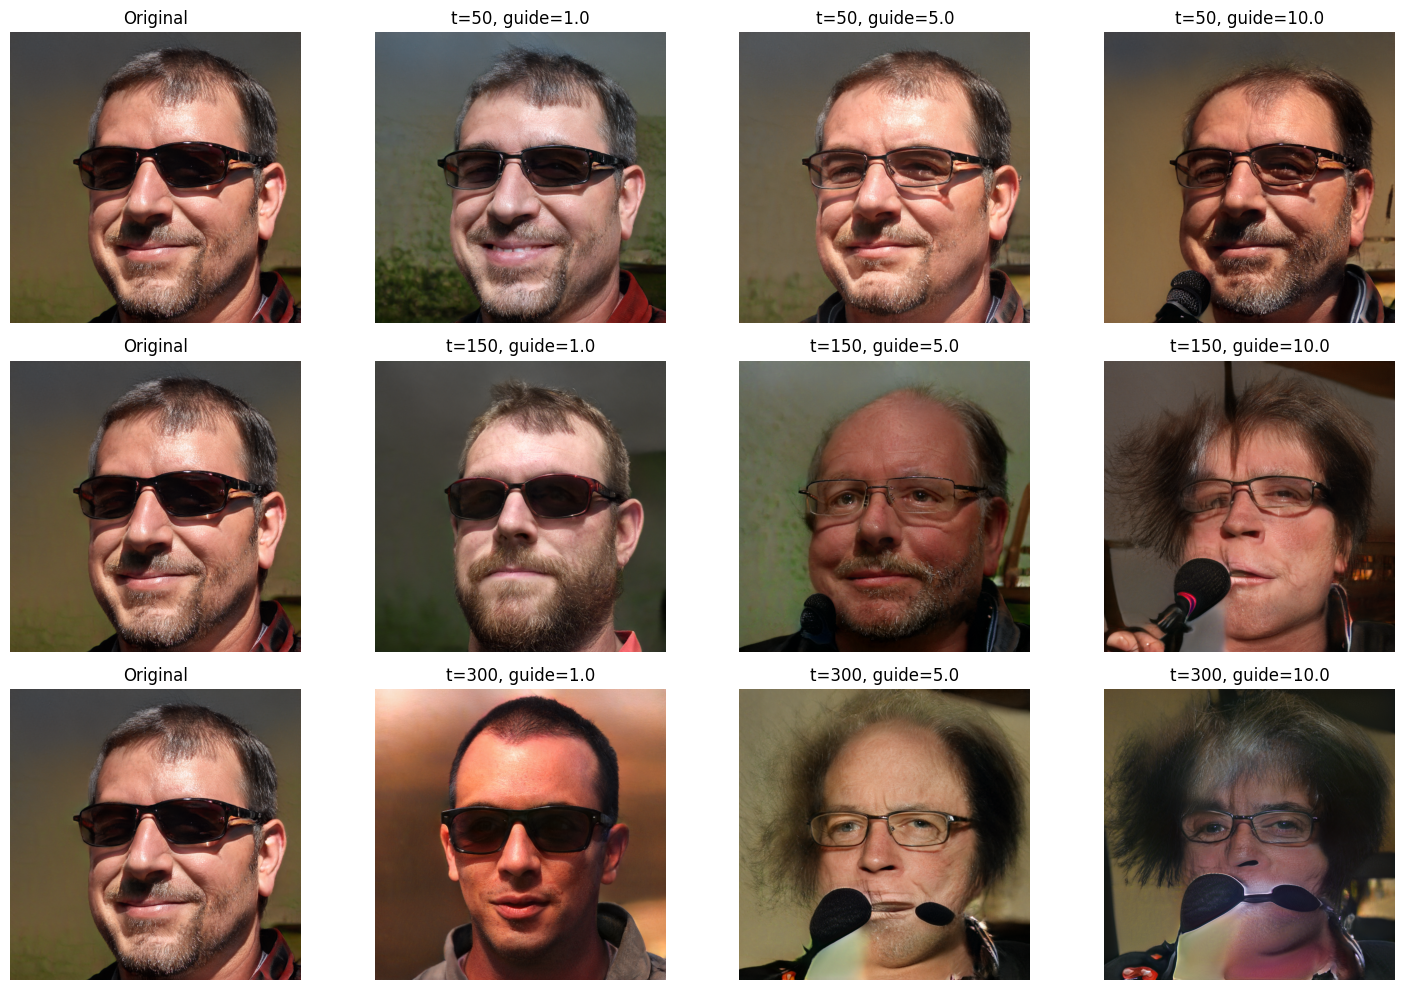

In [10]:
import matplotlib.pyplot as plt

def run_experiments(source_idx=0, target_label=1.0):
    """
    Generates a grid of images:
    Rows: Different Noise Levels (t_start)
    Cols: Different Guidance Scales
    """
    
    # Setup Parameters
    noise_levels = [50, 150, 300]   # Low, Medium, High Noise 
    guidance_scales = [1.0, 5.0, 10.0] # Weak, Normal, Strong Guidance 
    
    # Get Source Vector
    w_source = w_data[source_idx].unsqueeze(0).to(device)
    
    # Create Plot Grid
    # +1 column for the Original Image
    fig, axes = plt.subplots(len(noise_levels), len(guidance_scales) + 1, figsize=(15, 10))
    
    print(f"Running Experiment on Face ID: {source_idx}...")
    
    for row, t in enumerate(noise_levels):
        # Column 0: Always show Original Source (for comparison)
        w_expanded = w_source.unsqueeze(1).repeat(1, 18, 1)
        img_source = G.synthesis(w_expanded, noise_mode='const')
        img_disp = (img_source.permute(0, 2, 3, 1).clamp(-1, 1).detach().cpu().numpy()[0] + 1) / 2
        
        axes[row, 0].imshow(img_disp)
        axes[row, 0].set_title(f"Original")
        axes[row, 0].axis('off')
        
        # Columns 1-3: Edited Images
        for col, g in enumerate(guidance_scales):
            print(f"  > Sampling: t={t}, guidance={g}...")
            
            # Run SDE Edit
            w_edited = sde_edit(w_source, target_label=target_label, start_t=t, guidance_scale=g)
            
            # Generate Image
            w_edited_expanded = w_edited.unsqueeze(1).repeat(1, 18, 1)
            img_edited = G.synthesis(w_edited_expanded, noise_mode='const')
            
            # Process for Display
            img_disp = (img_edited.permute(0, 2, 3, 1).clamp(-1, 1).detach().cpu().numpy()[0] + 1) / 2
            
            axes[row, col+1].imshow(img_disp)
            axes[row, col+1].set_title(f"t={t}, guide={g}")
            axes[row, col+1].axis('off')

    plt.tight_layout()
    plt.savefig(f"experiment_face_{source_idx}.png") # Save for your report!
    plt.show()


run_experiments(source_idx=41, target_label=1.0) # Target 1.0 = Male, 0.0 = Female